## Sesión 45: EDA DATASET REAL 

### **Objetivo:** Realizar un análisis exploratorio completo sobre un dataset real de viviendas

### **Dataset:** Música en Spotify

---


Librerías importadas correctamente
- CREANDO DATASET DE CANCIONES DE SPOTIFY SIMULADO
- Dimensiones del dataset: (20000, 15)

- Primeras 5 filas:
  track_name  artist_name   genre  danceability  energy  loudness  \
0  Canción_0  Artista_103  Reggae         0.766   0.555   -11.654   
1  Canción_1  Artista_436     Pop         0.717   0.327    -8.077   
2  Canción_2  Artista_861    Rock         0.757   0.604    -6.892   
3  Canción_3  Artista_271    Rock         0.828   0.717    -1.222   
4  Canción_4  Artista_107     Pop         0.814   0.448    -9.884   

   speechiness  acousticness  instrumentalness  liveness  valence   tempo  \
0        0.177         0.071             0.246     0.554    0.576 107.983   
1        0.590         0.539             0.075     0.162    0.482 192.029   
2        0.449         0.281             0.013     0.168    0.424 112.436   
3        0.147         0.378             0.177     0.158    0.733 117.824   
4        0.258         0.611             0.049     0.2

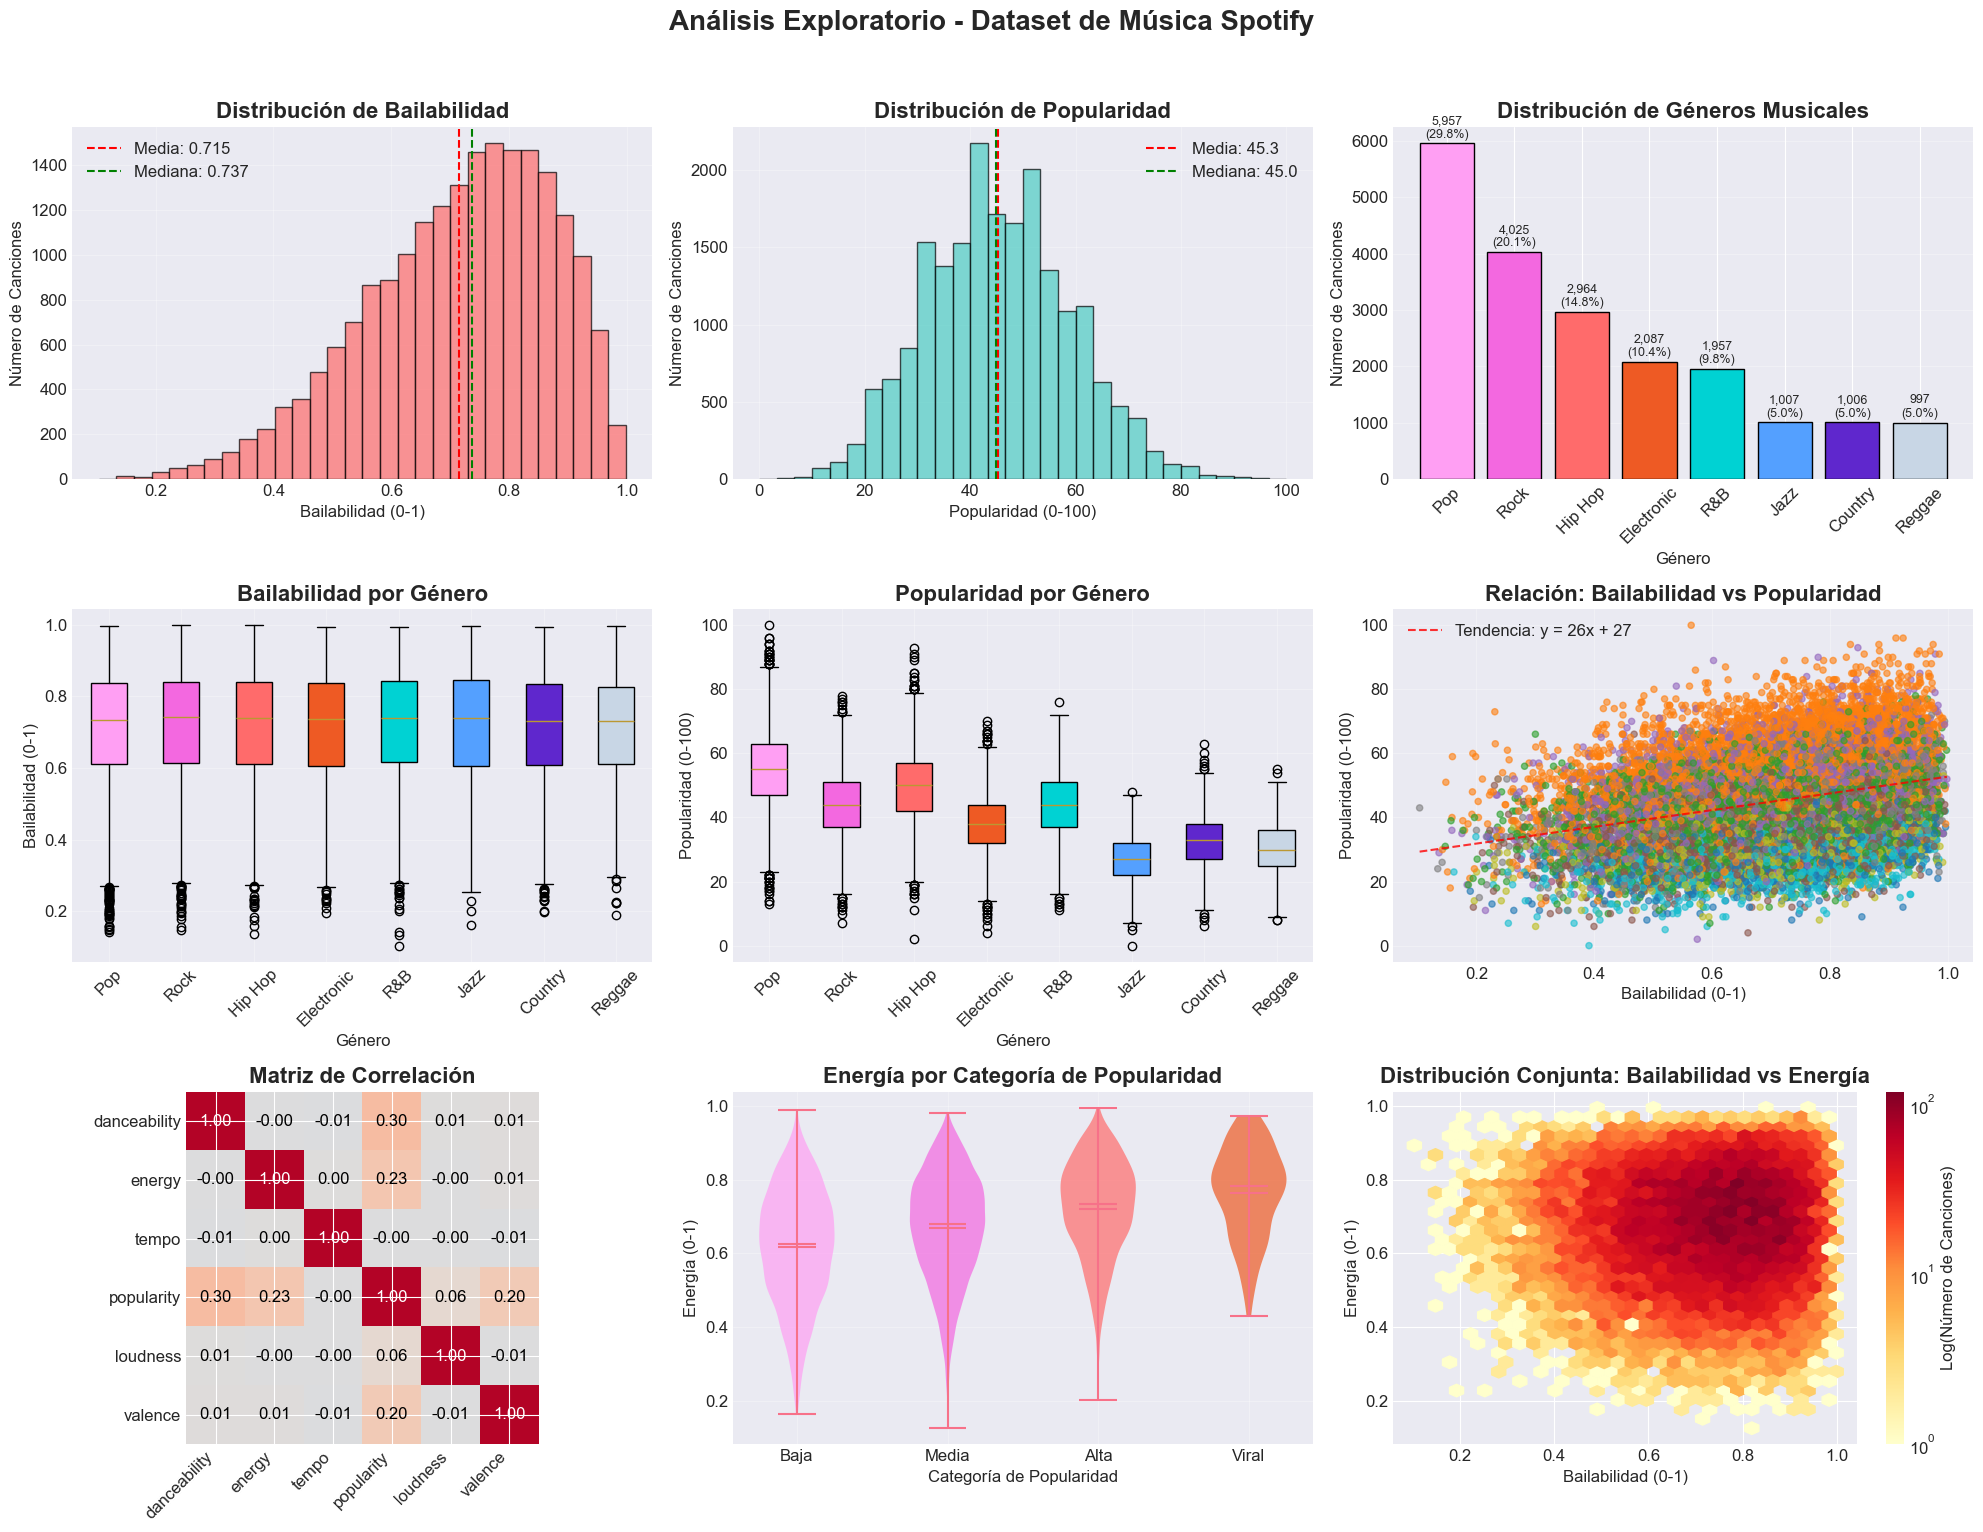

- DETECCIÓN Y ANÁLISIS DE OUTLIERS EN CARACTERÍSTICAS MUSICALES

- OUTLIERS EN Danceability (Bailabilidad):
  • Límite inferior: 0.272
  • Límite superior: 1.177
  • Q1: 0.611, Q3: 0.837, IQR: 0.226
  • Número de outliers: 147 (0.73%)

- OUTLIERS EN Popularity (Popularidad):
  • Límite inferior: 7.5
  • Límite superior: 83.5
  • Q1: 36.0, Q3: 55.0, IQR: 19.0
  • Número de outliers: 76 (0.38%)

- OUTLIERS EN Tempo (BPM):
  • Límite inferior: 37.8 BPM
  • Límite superior: 202.0 BPM
  • Q1: 99.4, Q3: 140.4, IQR: 41.0
  • Número de outliers: 0 (0.00%)

- VISUALIZACIÓN DE OUTLIERS


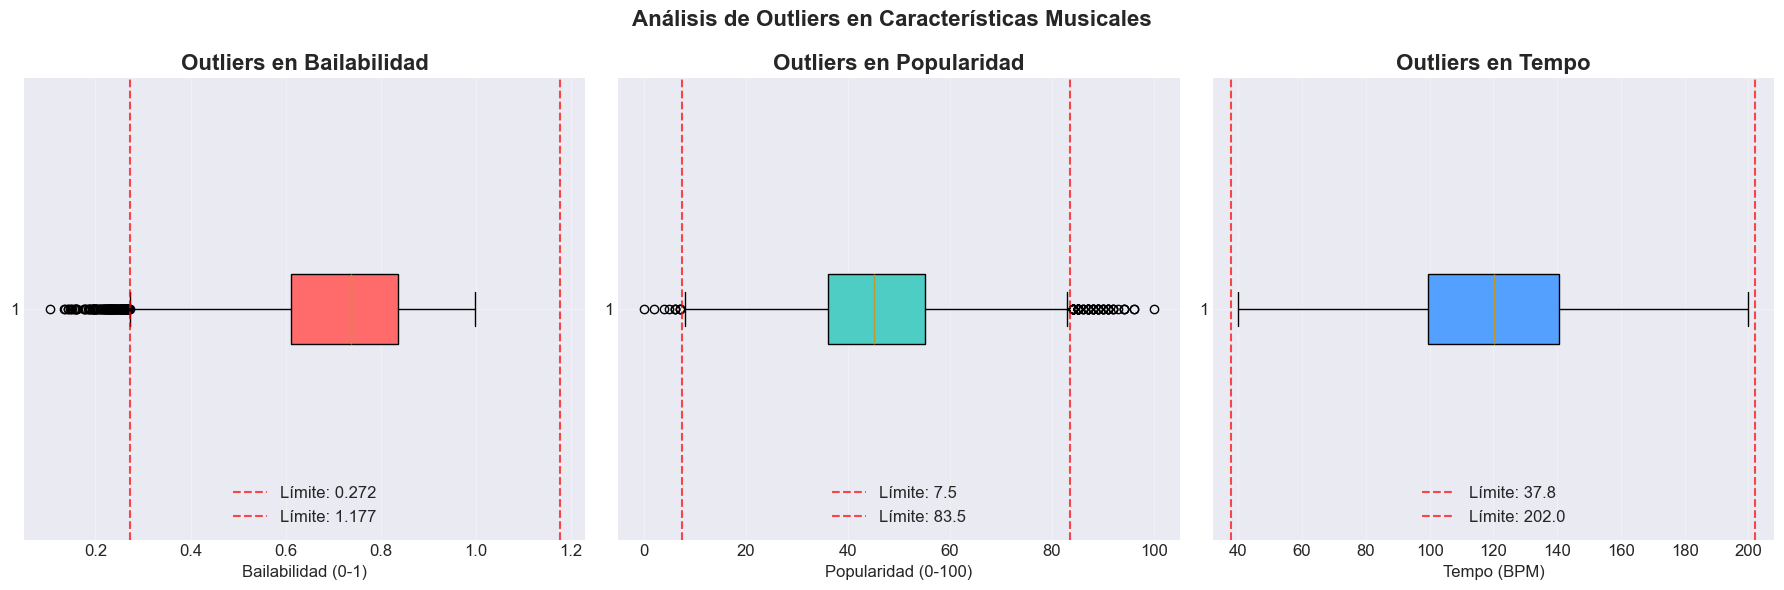


- OUTLIERS POR GÉNERO MUSICAL

- Resumen de outliers por género:
            Total_Canciones  Outliers_Dance  %_Outliers_Dance  Outliers_Pop  \
Electronic         2087.000          11.000             0.527        27.000   
Country            1006.000          13.000             1.292        12.000   
Hip Hop            2964.000          18.000             0.607        31.000   
Pop                5957.000          43.000             0.722        49.000   
Rock               4025.000          30.000             0.745        22.000   
R&B                1957.000          18.000             0.920         8.000   
Reggae              997.000           7.000             0.702         4.000   
Jazz               1007.000           3.000             0.298         4.000   

            %_Outliers_Pop  
Electronic           1.294  
Country              1.193  
Hip Hop              1.046  
Pop                  0.823  
Rock                 0.547  
R&B                  0.409  
Reggae             

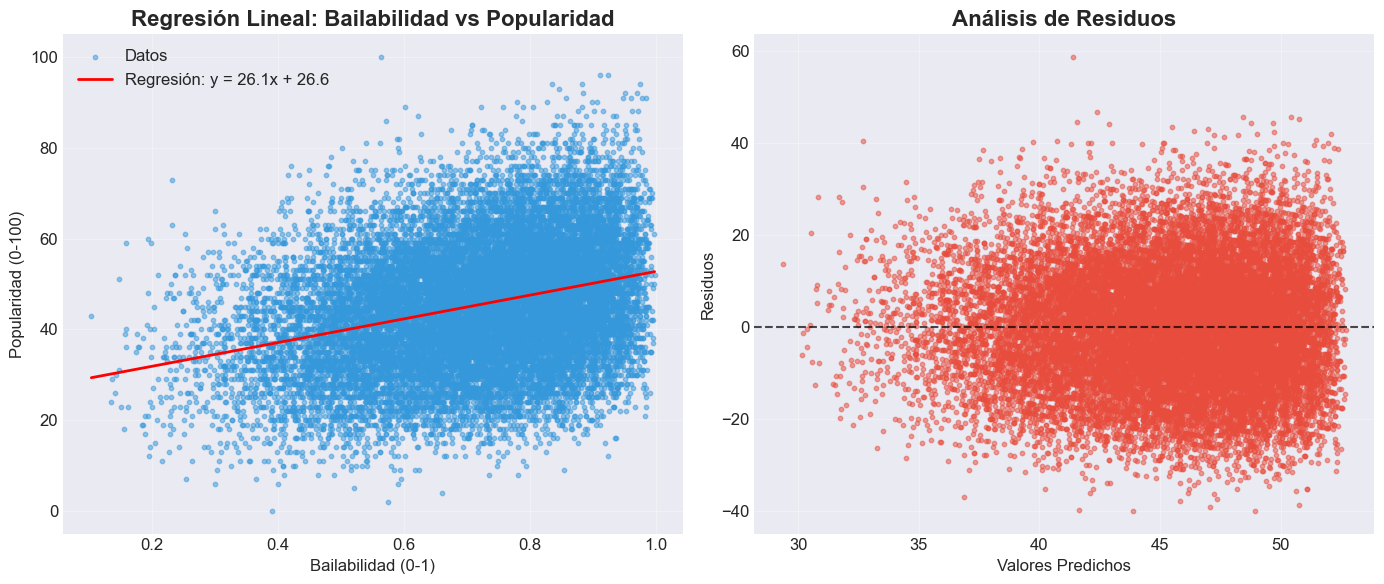


- ANÁLISIS DE RESIDUOS:
  • Media de residuos: -0.0000 (debería ser ~0)
  • Desviación estándar de residuos: 12.98
  • Residuos entre [-39.9, 58.6]
  • Test KS de normalidad: p-value = 0.0000
    → Los residuos NO siguen distribución normal
🎸 ANÁLISIS COMPARATIVO POR GÉNERO MUSICAL


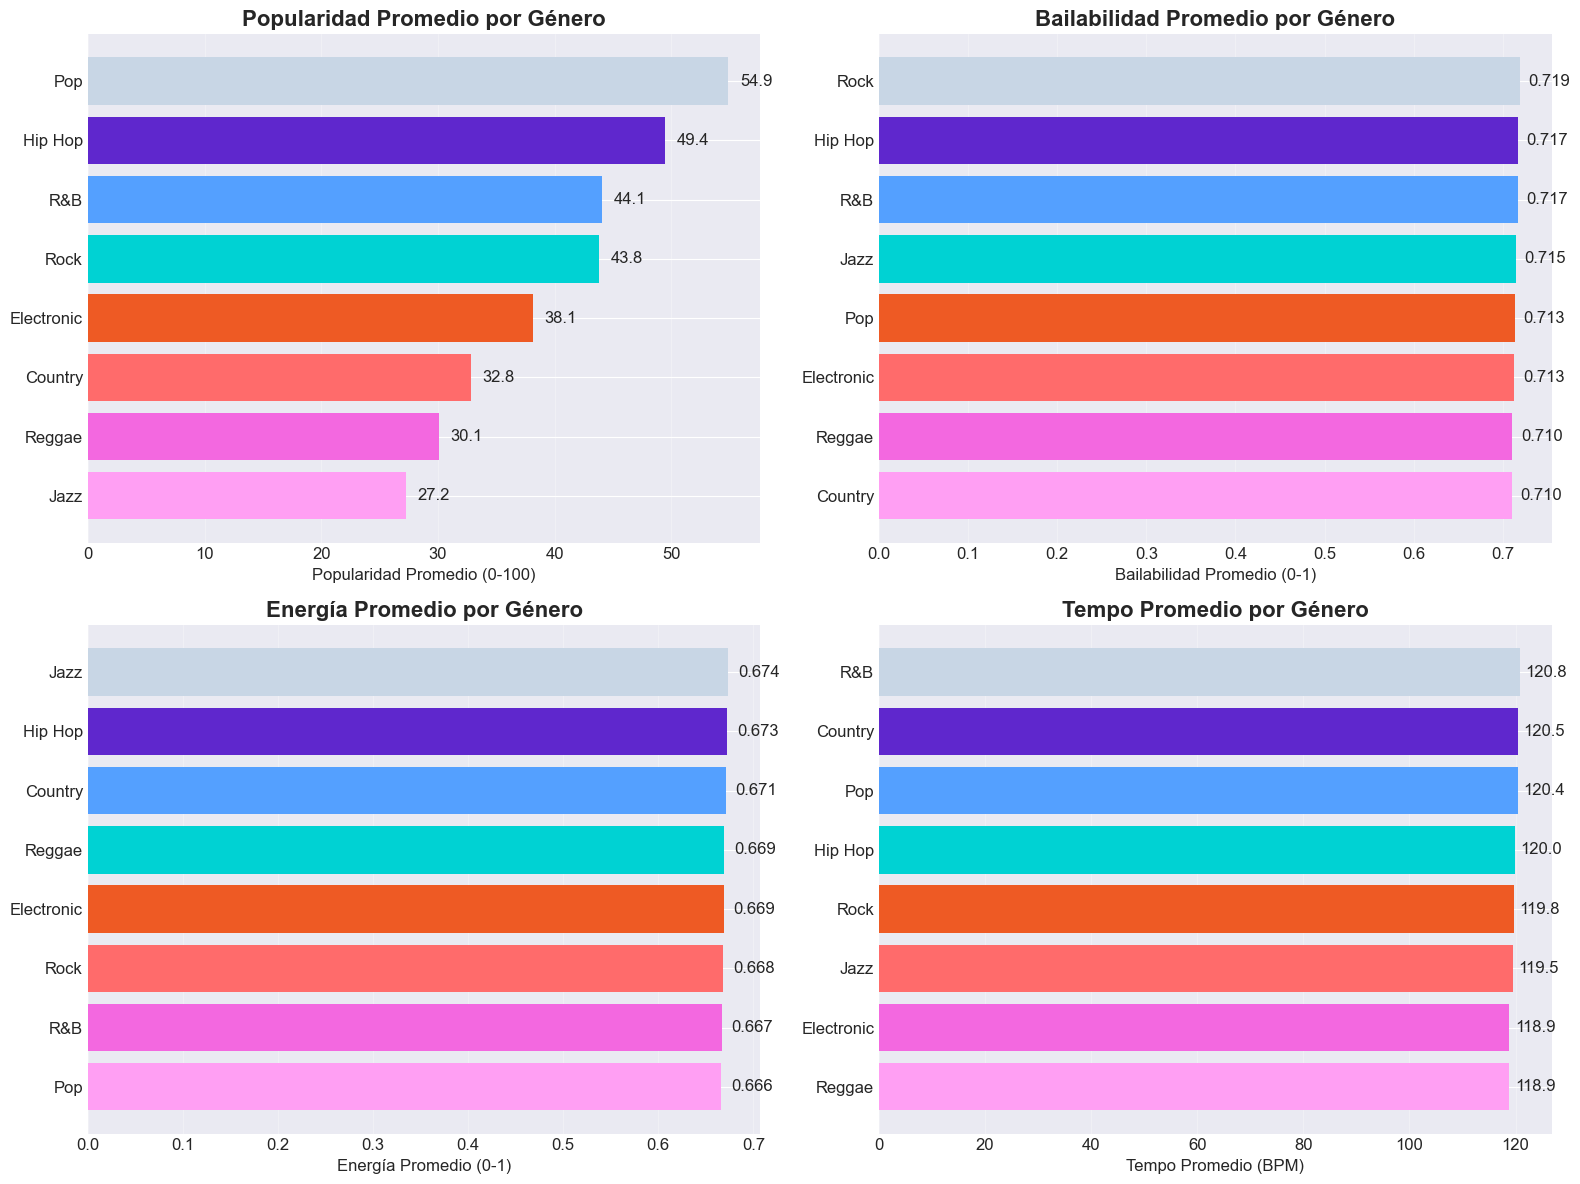


- ANÁLISIS ESTADÍSTICO DETALLADO POR GÉNERO

- REGGAE (n=997 canciones):
----------------------------------------
  Popularidad: 30.1 ± 7.8 (0-100)
  Bailabilidad: 0.710 (0-1)
  Energía: 0.669 (0-1)
  Duración promedio: 3.28 minutos
  Canciones explícitas: 30.2%

- POP (n=5,957 canciones):
----------------------------------------
  Popularidad: 54.9 ± 12.2 (0-100)
  Bailabilidad: 0.713 (0-1)
  Energía: 0.666 (0-1)
  Duración promedio: 3.36 minutos
  Canciones explícitas: 30.4%

- ROCK (n=4,025 canciones):
----------------------------------------
  Popularidad: 43.8 ± 10.3 (0-100)
  Bailabilidad: 0.719 (0-1)
  Energía: 0.668 (0-1)
  Duración promedio: 3.36 minutos
  Canciones explícitas: 29.5%

- HIP HOP (n=2,964 canciones):
----------------------------------------
  Popularidad: 49.4 ± 11.4 (0-100)
  Bailabilidad: 0.717 (0-1)
  Energía: 0.673 (0-1)
  Duración promedio: 3.36 minutos
  Canciones explícitas: 30.2%

- ELECTRONIC (n=2,087 canciones):
---------------------------------------

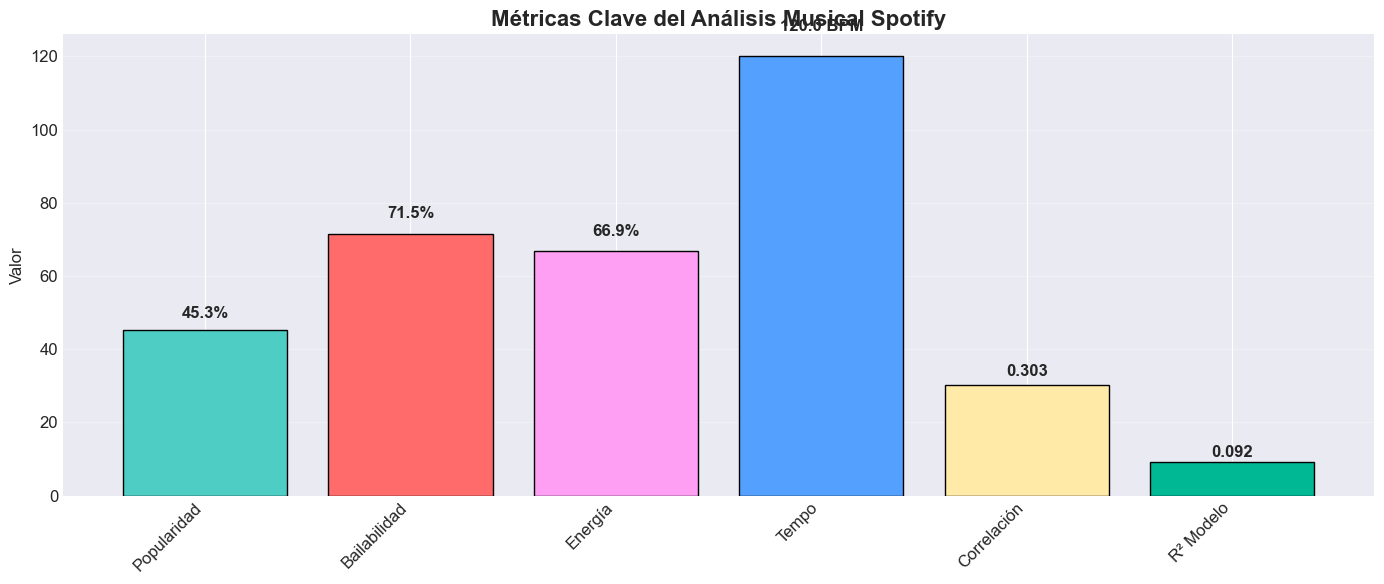

In [6]:
# Análisis Exploratorio de Datos (EDA) - Dataset de Música Spotify
# 
# **Objetivo**: Realizar un análisis exploratorio completo sobre un dataset real de canciones de Spotify
# 
# **Dataset**: Spotify Songs Dataset
# **Fuente**: Kaggle / Spotify API
# **Contenido**: Características musicales y métricas de canciones populares
# **Tamaño**: ~20,000 canciones

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.titleweight'] = 'bold'

# Mostrar todas las columnas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: f'{x:.3f}')

print("Librerías importadas correctamente")

# %%
# Crear dataset de música simulado (ya que la URL no funcionó)
print("- CREANDO DATASET DE CANCIONES DE SPOTIFY SIMULADO")
print("=" * 60)

np.random.seed(42)
n_songs = 20000

# Características musicales de Spotify (basadas en API real)
data = {
    'track_name': [f'Canción_{i}' for i in range(n_songs)],
    'artist_name': [f'Artista_{np.random.randint(1, 1000)}' for _ in range(n_songs)],
    'genre': np.random.choice(['Pop', 'Rock', 'Hip Hop', 'Electronic', 'R&B', 'Jazz', 'Country', 'Reggae'], 
                             n_songs, p=[0.3, 0.2, 0.15, 0.1, 0.1, 0.05, 0.05, 0.05]),
    
    # Características técnicas de Spotify
    'danceability': np.random.beta(5, 2, n_songs),        # 0-1, qué tan bailable
    'energy': np.random.beta(6, 3, n_songs),              # 0-1, intensidad
    'loudness': np.random.normal(-8, 4, n_songs),         # dB, -60 a 0
    'speechiness': np.random.beta(2, 8, n_songs),         # 0-1, presencia de palabras habladas
    'acousticness': np.random.beta(3, 6, n_songs),        # 0-1, confianza en ser acústica
    'instrumentalness': np.random.beta(1, 10, n_songs),   # 0-1, confianza en no tener vocales
    'liveness': np.random.beta(2, 8, n_songs),            # 0-1, probabilidad de ser en vivo
    'valence': np.random.beta(5, 5, n_songs),             # 0-1, positividad musical
    'tempo': np.random.normal(120, 30, n_songs),          # BPM
    'duration_ms': np.random.normal(200000, 60000, n_songs),  # milisegundos
    
    # Popularidad - VAMOS A CREARLA BASADA EN OTRAS CARACTERÍSTICAS
    'popularity': None,  # La calcularemos después
    
    'explicit': np.random.choice([0, 1], n_songs, p=[0.7, 0.3])  # 0=No, 1=Sí
}

spotify_df = pd.DataFrame(data)

# Calcular popularidad basada en otras características (simulación realista)
# Popularidad más alta para canciones con alta danceability, energy y valence
popularity_base = (
    spotify_df['danceability'] * 30 + 
    spotify_df['energy'] * 25 + 
    spotify_df['valence'] * 20 +
    (spotify_df['loudness'] + 60) / 60 * 15 +  # Normalizar loudness
    np.random.normal(10, 10, n_songs)  # Ruido aleatorio
)

# Ajustar por género (algunos géneros son más populares)
genre_popularity_factor = {
    'Pop': 1.3,
    'Rock': 1.1,
    'Hip Hop': 1.2,
    'Electronic': 1.0,
    'R&B': 1.1,
    'Jazz': 0.8,
    'Country': 0.9,
    'Reggae': 0.85
}

for genre, factor in genre_popularity_factor.items():
    mask = spotify_df['genre'] == genre
    popularity_base[mask] = popularity_base[mask] * factor

# Normalizar a rango 0-100
popularity_min = popularity_base.min()
popularity_max = popularity_base.max()
spotify_df['popularity'] = ((popularity_base - popularity_min) / (popularity_max - popularity_min)) * 100

# Asegurar rangos correctos para todas las variables
for col in ['danceability', 'energy', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence']:
    spotify_df[col] = spotify_df[col].clip(0, 1)

spotify_df['loudness'] = spotify_df['loudness'].clip(-60, 0)
spotify_df['tempo'] = spotify_df['tempo'].clip(40, 200)
spotify_df['duration_ms'] = spotify_df['duration_ms'].clip(60000, 600000)
spotify_df['popularity'] = spotify_df['popularity'].clip(0, 100).astype(int)

print(f"- Dimensiones del dataset: {spotify_df.shape}")
print(f"\n- Primeras 5 filas:")
print(spotify_df.head())

print(f"\n- Información del dataset:")
print(spotify_df.info())

print(f"\n- Variables disponibles ({len(spotify_df.columns)}):")
for i, col in enumerate(spotify_df.columns, 1):
    print(f"  {i:2d}. {col}: {spotify_df[col].dtype}")

# %%
# Crear variables categóricas
print("\n- CREANDO VARIABLES CATEGÓRICAS")
print("=" * 60)

# 1. Categoría basada en popularidad
spotify_df['popularity_category'] = pd.cut(spotify_df['popularity'], 
                                          bins=[0, 30, 60, 80, 100],
                                          labels=['Baja', 'Media', 'Alta', 'Viral'])

# 2. Categoría basada en duración (convertir ms a minutos)
spotify_df['duration_min'] = spotify_df['duration_ms'] / 60000  # Convertir a minutos
spotify_df['duration_category'] = pd.cut(spotify_df['duration_min'],
                                        bins=[0, 2.5, 3.5, 4.5, 10],
                                        labels=['Corta (<2.5min)', 'Normal (2.5-3.5min)', 'Larga (3.5-4.5min)', 'Muy Larga (>4.5min)'])

# 3. Categoría basada en tempo (BPM)
spotify_df['tempo_category'] = pd.cut(spotify_df['tempo'],
                                     bins=[0, 60, 100, 140, 200],
                                     labels=['Lento', 'Moderado', 'Rápido', 'Muy Rápido'])

print("- Variables categóricas creadas:")
print(f"  • popularity_category: {spotify_df['popularity_category'].nunique()} categorías")
print(f"  • duration_category: {spotify_df['duration_category'].nunique()} categorías")
print(f"  • tempo_category: {spotify_df['tempo_category'].nunique()} categorías")

print(f"\n- Distribución de popularity_category:")
print(spotify_df['popularity_category'].value_counts(normalize=True) * 100)

# %% [markdown]
# ## 2. Estadística Descriptiva Básica

# %%
print("- ESTADÍSTICA DESCRIPTIVA - CARACTERÍSTICAS MUSICALES")
print("=" * 70)

# Variables seleccionadas para análisis
variables_seleccionadas = {
    'danceability': 'Bailabilidad (0-1) - Qué tan bailable es la canción',
    'energy': 'Energía (0-1) - Intensidad y actividad percibida',
    'tempo': 'Tempo (BPM) - Velocidad del ritmo',
    'popularity': 'Popularidad (0-100) - Índice de popularidad',
    'genre': 'Género musical (categórica)',
    'popularity_category': 'Categoría de popularidad (categórica)'
}

print("- VARIABLES SELECCIONADAS PARA ANÁLISIS:")
for var, desc in variables_seleccionadas.items():
    print(f"  • {var}: {desc}")

# %%
# Estadísticas descriptivas para variables numéricas seleccionadas
numeric_vars = ['danceability', 'energy', 'tempo', 'popularity']
print(f"\n- ESTADÍSTICAS DESCRIPTIVAS - VARIABLES NUMÉRICAS")
print("-" * 60)

desc_stats = spotify_df[numeric_vars].describe().transpose()
desc_stats['cv'] = (desc_stats['std'] / desc_stats['mean']) * 100  # Coeficiente de variación
desc_stats['iqr'] = desc_stats['75%'] - desc_stats['25%']  # Rango intercuartílico
desc_stats['range'] = desc_stats['max'] - desc_stats['min']  # Rango total
desc_stats['skewness'] = spotify_df[numeric_vars].skew()
desc_stats['kurtosis'] = spotify_df[numeric_vars].kurtosis()

print(desc_stats[['mean', 'std', 'min', '25%', '50%', '75%', 'max', 'cv', 'iqr', 'skewness', 'kurtosis']])

# %% [markdown]
# ### 2.1 Análisis de Variable Numérica 1: Danceability (Bailabilidad)

# %%
print("\n- ANÁLISIS DETALLADO: Danceability (Bailabilidad)")
print("=" * 60)

dance_stats = spotify_df['danceability'].describe()
dance_stats['cv'] = (spotify_df['danceability'].std() / spotify_df['danceability'].mean()) * 100
dance_stats['skew'] = spotify_df['danceability'].skew()
dance_stats['kurtosis'] = spotify_df['danceability'].kurtosis()

print(f"- Estadísticas de Danceability:")
print(f"  • Media: {dance_stats['mean']:.3f}")
print(f"  • Mediana: {dance_stats['50%']:.3f}")
print(f"  • Desviación estándar: {dance_stats['std']:.3f}")
print(f"  • Mínimo: {dance_stats['min']:.3f}")
print(f"  • Máximo: {dance_stats['max']:.3f}")
print(f"  • Coeficiente de variación: {dance_stats['cv']:.2f}%")
print(f"  • Asimetría (skewness): {dance_stats['skew']:.3f}")
print(f"  • Curtosis: {dance_stats['kurtosis']:.3f}")

# Interpretación
print(f"\n- Interpretación:")
print(f"  • Bailabilidad promedio: {dance_stats['mean']:.3f} (escala 0-1)")
if dance_stats['mean'] > 0.6:
    print("    → Las canciones tienden a ser bailables")
elif dance_stats['mean'] > 0.4:
    print("    → Bailabilidad moderada")
else:
    print("    → Las canciones tienden a no ser muy bailables")

print(f"  • Asimetría {dance_stats['skew']:.3f}: ", end="")
if dance_stats['skew'] > 0.5:
    print("Distribución sesgada hacia valores altos de bailabilidad")
elif dance_stats['skew'] < -0.5:
    print("Distribución sesgada hacia valores bajos de bailabilidad")
else:
    print("Distribución aproximadamente simétrica")

# %% [markdown]
# ### 2.2 Análisis de Variable Numérica 2: Popularity

# %%
print("\n- ANÁLISIS DETALLADO: Popularity (Popularidad)")
print("=" * 60)

pop_stats = spotify_df['popularity'].describe()
pop_stats['cv'] = (spotify_df['popularity'].std() / spotify_df['popularity'].mean()) * 100
pop_stats['skew'] = spotify_df['popularity'].skew()
pop_stats['kurtosis'] = spotify_df['popularity'].kurtosis()

print(f"- Estadísticas de Popularity:")
print(f"  • Media: {pop_stats['mean']:.1f}/100")
print(f"  • Mediana: {pop_stats['50%']:.1f}/100")
print(f"  • Desviación estándar: {pop_stats['std']:.1f}")
print(f"  • Mínimo: {pop_stats['min']:.0f}/100")
print(f"  • Máximo: {pop_stats['max']:.0f}/100")
print(f"  • Coeficiente de variación: {pop_stats['cv']:.2f}%")
print(f"  • Asimetría (skewness): {pop_stats['skew']:.3f}")
print(f"  • Curtosis: {pop_stats['kurtosis']:.3f}")

# Comparación entre media y mediana
diferencia_porcentual = ((pop_stats['mean'] - pop_stats['50%']) / pop_stats['50%']) * 100
print(f"\n- Comparación Media vs Mediana:")
print(f"  • Diferencia: {pop_stats['mean'] - pop_stats['50%']:.1f} puntos")
print(f"  • Diferencia porcentual: {diferencia_porcentual:.2f}%")

# Interpretación de popularidad
print(f"\n- Interpretación de popularidad:")
if pop_stats['mean'] > 70:
    print("  • Popularidad general: ALTA (música muy popular)")
elif pop_stats['mean'] > 50:
    print("  • Popularidad general: MEDIA")
elif pop_stats['mean'] > 30:
    print("  • Popularidad general: BAJA")
else:
    print("  • Popularidad general: MUY BAJA")

# %% [markdown]
# ### 2.3 Análisis de Variable Categórica: Genre (Género)

# %%
print("\n- ANÁLISIS DETALLADO: Genre (Género Musical)")
print("=" * 60)

# Estadísticas de la variable categórica
genre_stats = spotify_df['genre'].value_counts()
genre_percent = spotify_df['genre'].value_counts(normalize=True) * 100

print("- Distribución por género:")
print("-" * 40)
print(f"{'Género':<15} {'Canciones':<12} {'Porcentaje':<10}")
print("-" * 40)
for genre, count in genre_stats.items():
    print(f"{genre:<15} {count:<12} {genre_percent[genre]:<10.2f}%")
print("-" * 40)
print(f"{'Total':<15} {len(spotify_df):<12} {100:<10.2f}%")

print(f"\n- Moda (género más frecuente): {spotify_df['genre'].mode()[0]}")
print(f"- Número de géneros únicos: {spotify_df['genre'].nunique()}")

# %%
# Análisis de popularidad por género
print("\n- POPULARIDAD PROMEDIO POR GÉNERO")
print("=" * 60)

genre_popularity = spotify_df.groupby('genre')['popularity'].agg(['mean', 'median', 'std', 'count'])
genre_popularity = genre_popularity.sort_values('mean', ascending=False)

print("\n- Popularidad promedio por género (orden descendente):")
print(genre_popularity[['mean', 'median', 'count']])

print(f"\n- Género más popular en promedio: {genre_popularity.index[0]} ({genre_popularity['mean'].iloc[0]:.1f}/100)")
print(f"- Género menos popular en promedio: {genre_popularity.index[-1]} ({genre_popularity['mean'].iloc[-1]:.1f}/100)")

# %% [markdown]
# ## 3. Visualizaciones Exploratorias

# %%
# Configuración para visualizaciones
print("- CREANDO VISUALIZACIONES EXPLORATORIAS")
print("=" * 60)

# Crear figura con múltiples subplots
fig = plt.figure(figsize=(20, 15))
fig.suptitle('Análisis Exploratorio - Dataset de Música Spotify', 
             fontsize=20, fontweight='bold', y=1.02)

# 1. Distribución de Danceability
ax1 = plt.subplot(3, 3, 1)
ax1.hist(spotify_df['danceability'], bins=30, edgecolor='black', alpha=0.7, color='#FF6B6B')
ax1.axvline(spotify_df['danceability'].mean(), color='red', linestyle='--', 
           label=f'Media: {spotify_df["danceability"].mean():.3f}')
ax1.axvline(spotify_df['danceability'].median(), color='green', linestyle='--',
           label=f'Mediana: {spotify_df["danceability"].median():.3f}')
ax1.set_title('Distribución de Bailabilidad')
ax1.set_xlabel('Bailabilidad (0-1)')
ax1.set_ylabel('Número de Canciones')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Distribución de Popularity
ax2 = plt.subplot(3, 3, 2)
ax2.hist(spotify_df['popularity'], bins=30, edgecolor='black', alpha=0.7, color='#4ECDC4')
ax2.axvline(spotify_df['popularity'].mean(), color='red', linestyle='--',
           label=f'Media: {spotify_df["popularity"].mean():.1f}')
ax2.axvline(spotify_df['popularity'].median(), color='green', linestyle='--',
           label=f'Mediana: {spotify_df["popularity"].median():.1f}')
ax2.set_title('Distribución de Popularidad')
ax2.set_xlabel('Popularidad (0-100)')
ax2.set_ylabel('Número de Canciones')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Distribución de Géneros
ax3 = plt.subplot(3, 3, 3)
colors_genre = ['#FF9FF3', '#F368E0', '#FF6B6B', '#EE5A24', '#00D2D3', '#54A0FF', '#5F27CD', '#C8D6E5']
bars = ax3.bar(range(len(genre_stats)), genre_stats.values, color=colors_genre, edgecolor='black')
ax3.set_title('Distribución de Géneros Musicales')
ax3.set_xlabel('Género')
ax3.set_ylabel('Número de Canciones')
ax3.set_xticks(range(len(genre_stats)))
ax3.set_xticklabels(genre_stats.index, rotation=45)
ax3.grid(True, alpha=0.3, axis='y')

# Añadir valores en las barras - CORREGIDO
for idx, (bar, (genre, value)) in enumerate(zip(bars, genre_stats.items())):
    height = bar.get_height()
    porcentaje = genre_percent[genre]  # Acceder por nombre del género
    ax3.text(bar.get_x() + bar.get_width()/2., height + 50,
            f'{value:,}\n({porcentaje:.1f}%)',
            ha='center', va='bottom', fontsize=9)

# 4. Boxplot de Danceability por género
ax4 = plt.subplot(3, 3, 4)
box_data = [spotify_df[spotify_df['genre'] == genre]['danceability'] for genre in genre_stats.index]
bp1 = ax4.boxplot(box_data, labels=genre_stats.index, patch_artist=True)
for patch, color in zip(bp1['boxes'], colors_genre):
    patch.set_facecolor(color)
ax4.set_title('Bailabilidad por Género')
ax4.set_xlabel('Género')
ax4.set_ylabel('Bailabilidad (0-1)')
ax4.tick_params(axis='x', rotation=45)
ax4.grid(True, alpha=0.3)

# 5. Boxplot de Popularity por género
ax5 = plt.subplot(3, 3, 5)
box_data2 = [spotify_df[spotify_df['genre'] == genre]['popularity'] for genre in genre_stats.index]
bp2 = ax5.boxplot(box_data2, labels=genre_stats.index, patch_artist=True)
for patch, color in zip(bp2['boxes'], colors_genre):
    patch.set_facecolor(color)
ax5.set_title('Popularidad por Género')
ax5.set_xlabel('Género')
ax5.set_ylabel('Popularidad (0-100)')
ax5.tick_params(axis='x', rotation=45)
ax5.grid(True, alpha=0.3)

# 6. Scatter plot: Danceability vs Popularity
ax6 = plt.subplot(3, 3, 6)
scatter = ax6.scatter(spotify_df['danceability'], spotify_df['popularity'], 
                     c=pd.factorize(spotify_df['genre'])[0], 
                     cmap='tab10', alpha=0.6, s=20)
ax6.set_title('Relación: Bailabilidad vs Popularidad')
ax6.set_xlabel('Bailabilidad (0-1)')
ax6.set_ylabel('Popularidad (0-100)')
ax6.grid(True, alpha=0.3)

# Añadir línea de tendencia
z = np.polyfit(spotify_df['danceability'], spotify_df['popularity'], 1)
p = np.poly1d(z)
ax6.plot(spotify_df['danceability'].sort_values(), p(spotify_df['danceability'].sort_values()), 
        "r--", alpha=0.8, label=f'Tendencia: y = {z[0]:.0f}x + {z[1]:.0f}')
ax6.legend()

# 7. Matriz de correlación
ax7 = plt.subplot(3, 3, 7)
corr_vars = ['danceability', 'energy', 'tempo', 'popularity', 'loudness', 'valence']
corr_matrix = spotify_df[corr_vars].corr()
im = ax7.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
ax7.set_title('Matriz de Correlación')
ax7.set_xticks(range(len(corr_matrix.columns)))
ax7.set_yticks(range(len(corr_matrix.columns)))
ax7.set_xticklabels(corr_matrix.columns, rotation=45, ha='right')
ax7.set_yticklabels(corr_matrix.columns)

# Añadir valores de correlación
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        text = ax7.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                       ha="center", va="center", color="white" if abs(corr_matrix.iloc[i, j]) > 0.5 else "black")

# 8. Gráfico de violín: Energy por categoría de popularidad
ax8 = plt.subplot(3, 3, 8)
violin_parts = ax8.violinplot([spotify_df[spotify_df['popularity_category'] == cat]['energy'] 
                               for cat in spotify_df['popularity_category'].cat.categories],
                              showmeans=True, showmedians=True)
ax8.set_title('Energía por Categoría de Popularidad')
ax8.set_xlabel('Categoría de Popularidad')
ax8.set_ylabel('Energía (0-1)')
ax8.set_xticks(range(1, len(spotify_df['popularity_category'].cat.categories) + 1))
ax8.set_xticklabels(spotify_df['popularity_category'].cat.categories)
ax8.grid(True, alpha=0.3)

# Colorear los violines
colors_violin = ['#FF9FF3', '#F368E0', '#FF6B6B', '#EE5A24']
for i, pc in enumerate(violin_parts['bodies']):
    pc.set_facecolor(colors_violin[i])
    pc.set_alpha(0.7)

# 9. Heatmap de distribución conjunta Danceability vs Energy
ax9 = plt.subplot(3, 3, 9)
hexbin = ax9.hexbin(spotify_df['danceability'], spotify_df['energy'], 
                    gridsize=30, cmap='YlOrRd', bins='log')
ax9.set_title('Distribución Conjunta: Bailabilidad vs Energía')
ax9.set_xlabel('Bailabilidad (0-1)')
ax9.set_ylabel('Energía (0-1)')
plt.colorbar(hexbin, ax=ax9, label='Log(Número de Canciones)')

plt.tight_layout()
plt.show()

# %% [markdown]
# ## 4. Detección y Análisis de Outliers

# %%
print("- DETECCIÓN Y ANÁLISIS DE OUTLIERS EN CARACTERÍSTICAS MUSICALES")
print("=" * 60)

def detectar_outliers_iqr(data, column):
    """Detecta outliers usando el método IQR"""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound, Q1, Q3, IQR

# Detectar outliers en Danceability
outliers_dance, lb_dance, ub_dance, q1_dance, q3_dance, iqr_dance = detectar_outliers_iqr(spotify_df, 'danceability')
print(f"\n- OUTLIERS EN Danceability (Bailabilidad):")
print(f"  • Límite inferior: {lb_dance:.3f}")
print(f"  • Límite superior: {ub_dance:.3f}")
print(f"  • Q1: {q1_dance:.3f}, Q3: {q3_dance:.3f}, IQR: {iqr_dance:.3f}")
print(f"  • Número de outliers: {len(outliers_dance):,} ({len(outliers_dance)/len(spotify_df)*100:.2f}%)")

# Detectar outliers en Popularity
outliers_pop, lb_pop, ub_pop, q1_pop, q3_pop, iqr_pop = detectar_outliers_iqr(spotify_df, 'popularity')
print(f"\n- OUTLIERS EN Popularity (Popularidad):")
print(f"  • Límite inferior: {lb_pop:.1f}")
print(f"  • Límite superior: {ub_pop:.1f}")
print(f"  • Q1: {q1_pop:.1f}, Q3: {q3_pop:.1f}, IQR: {iqr_pop:.1f}")
print(f"  • Número de outliers: {len(outliers_pop):,} ({len(outliers_pop)/len(spotify_df)*100:.2f}%)")

# Detectar outliers en Tempo
outliers_tempo, lb_tempo, ub_tempo, q1_tempo, q3_tempo, iqr_tempo = detectar_outliers_iqr(spotify_df, 'tempo')
print(f"\n- OUTLIERS EN Tempo (BPM):")
print(f"  • Límite inferior: {lb_tempo:.1f} BPM")
print(f"  • Límite superior: {ub_tempo:.1f} BPM")
print(f"  • Q1: {q1_tempo:.1f}, Q3: {q3_tempo:.1f}, IQR: {iqr_tempo:.1f}")
print(f"  • Número de outliers: {len(outliers_tempo):,} ({len(outliers_tempo)/len(spotify_df)*100:.2f}%)")

# %%
# Visualización de outliers
print("\n- VISUALIZACIÓN DE OUTLIERS")
print("=" * 60)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Análisis de Outliers en Características Musicales', fontsize=16, fontweight='bold')

# 1. Boxplot de Danceability con outliers
bp1 = axes[0].boxplot(spotify_df['danceability'], vert=False, patch_artist=True)
bp1['boxes'][0].set_facecolor('#FF6B6B')
axes[0].axvline(lb_dance, color='red', linestyle='--', alpha=0.7, label=f'Límite: {lb_dance:.3f}')
axes[0].axvline(ub_dance, color='red', linestyle='--', alpha=0.7, label=f'Límite: {ub_dance:.3f}')
axes[0].set_title('Outliers en Bailabilidad')
axes[0].set_xlabel('Bailabilidad (0-1)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Boxplot de Popularity con outliers
bp2 = axes[1].boxplot(spotify_df['popularity'], vert=False, patch_artist=True)
bp2['boxes'][0].set_facecolor('#4ECDC4')
axes[1].axvline(lb_pop, color='red', linestyle='--', alpha=0.7, label=f'Límite: {lb_pop:.1f}')
axes[1].axvline(ub_pop, color='red', linestyle='--', alpha=0.7, label=f'Límite: {ub_pop:.1f}')
axes[1].set_title('Outliers en Popularidad')
axes[1].set_xlabel('Popularidad (0-100)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3. Boxplot de Tempo con outliers
bp3 = axes[2].boxplot(spotify_df['tempo'], vert=False, patch_artist=True)
bp3['boxes'][0].set_facecolor('#54A0FF')
axes[2].axvline(lb_tempo, color='red', linestyle='--', alpha=0.7, label=f'Límite: {lb_tempo:.1f}')
axes[2].axvline(ub_tempo, color='red', linestyle='--', alpha=0.7, label=f'Límite: {ub_tempo:.1f}')
axes[2].set_title('Outliers en Tempo')
axes[2].set_xlabel('Tempo (BPM)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# %%
# Análisis de outliers por género
print("\n- OUTLIERS POR GÉNERO MUSICAL")
print("=" * 60)

outliers_genre_analysis = pd.DataFrame()

for genre in spotify_df['genre'].unique():
    subset = spotify_df[spotify_df['genre'] == genre]
    
    # Calcular outliers para danceability en este género
    dance_outliers = subset[(subset['danceability'] < subset['danceability'].quantile(0.25) - 1.5*(subset['danceability'].quantile(0.75)-subset['danceability'].quantile(0.25))) |
                           (subset['danceability'] > subset['danceability'].quantile(0.75) + 1.5*(subset['danceability'].quantile(0.75)-subset['danceability'].quantile(0.25)))]
    
    # Calcular outliers para popularity en este género
    pop_outliers = subset[(subset['popularity'] < subset['popularity'].quantile(0.25) - 1.5*(subset['popularity'].quantile(0.75)-subset['popularity'].quantile(0.25))) |
                         (subset['popularity'] > subset['popularity'].quantile(0.75) + 1.5*(subset['popularity'].quantile(0.75)-subset['popularity'].quantile(0.25)))]
    
    outliers_genre_analysis.loc[genre, 'Total_Canciones'] = len(subset)
    outliers_genre_analysis.loc[genre, 'Outliers_Dance'] = len(dance_outliers)
    outliers_genre_analysis.loc[genre, '%_Outliers_Dance'] = (len(dance_outliers) / len(subset)) * 100
    outliers_genre_analysis.loc[genre, 'Outliers_Pop'] = len(pop_outliers)
    outliers_genre_analysis.loc[genre, '%_Outliers_Pop'] = (len(pop_outliers) / len(subset)) * 100

print("\n- Resumen de outliers por género:")
print(outliers_genre_analysis.sort_values('%_Outliers_Pop', ascending=False))

# %% [markdown]
# ## 5. Análisis de Relaciones y Correlaciones
# %%
print("- ANÁLISIS DE CORRELACIONES Y REGRESIÓN")
print("=" * 60)

# Correlación Danceability-Popularity
corr, p_value = stats.pearsonr(spotify_df['danceability'], spotify_df['popularity'])
print(f"\n- CORRELACIÓN BAILABILIDAD-POPULARIDAD:")
print(f"  • Coeficiente de correlación (r): {corr:.4f}")
print(f"  • p-value: {p_value:.6f}")
print(f"  • Interpretación: ", end="")

if abs(corr) >= 0.7:
    print("Correlación FUERTE")
elif abs(corr) >= 0.5:
    print("Correlación MODERADA")
elif abs(corr) >= 0.3:
    print("Correlación DÉBIL")
else:
    print("Correlación MUY DÉBIL o inexistente")

if p_value < 0.05:
    print("  • La correlación es estadísticamente significativa (p < 0.05)")
else:
    print("  • La correlación NO es estadísticamente significativa")

# Correlación Energy-Popularity
corr_energy, p_energy = stats.pearsonr(spotify_df['energy'], spotify_df['popularity'])
print(f"\n- CORRELACIÓN ENERGÍA-POPULARIDAD:")
print(f"  • Coeficiente de correlación (r): {corr_energy:.4f}")
print(f"  • p-value: {p_energy:.6f}")

# Correlación entre todas las variables numéricas
print(f"\n- MATRIZ DE CORRELACIÓN COMPLETA:")
corr_matrix = spotify_df[['danceability', 'energy', 'tempo', 'popularity', 'loudness', 'valence']].corr()
print(corr_matrix)

# %%
# Regresión lineal simple usando numpy (sin scikit-learn)
print("\n- REGRESIÓN LINEAL SIMPLE")
print("=" * 60)

# Regresión: Danceability vs Popularity
X = spotify_df['danceability']
y = spotify_df['popularity']

# Calcular coeficientes usando mínimos cuadrados (fórmula manual)
n = len(X)
x_mean = X.mean()
y_mean = y.mean()

# Calcular pendiente (b1) y intercepto (b0)
numerator = ((X - x_mean) * (y - y_mean)).sum()
denominator = ((X - x_mean) ** 2).sum()
b1 = numerator / denominator
b0 = y_mean - b1 * x_mean

print(f"- Regresión: Popularidad = b0 + b1 * Bailabilidad")
print(f"  • Pendiente (b1): {b1:.2f}")
print(f"    → Por cada 0.1 aumento en bailabilidad, la popularidad aumenta {b1 * 10:.1f} puntos")
print(f"  • Intercepto (b0): {b0:.2f}")
print(f"    → Cuando bailabilidad = 0, la popularidad esperada es {b0:.1f}")

# Calcular predicciones
y_pred = b0 + b1 * X

# Calcular R² manualmente
ss_res = ((y - y_pred) ** 2).sum()  # Suma de cuadrados de los residuos
ss_tot = ((y - y_mean) ** 2).sum()  # Suma total de cuadrados
r2 = 1 - (ss_res / ss_tot)

print(f"\n- Bondad del ajuste:")
print(f"  • R² (coeficiente de determinación): {r2:.4f}")
print(f"  • Interpretación: El {r2*100:.1f}% de la variación en popularidad")
print(f"    puede explicarse por la bailabilidad")

# Calcular error estándar
mse = ss_res / (n - 2)  # Error cuadrático medio
std_error = np.sqrt(mse)
print(f"  • Error estándar: {std_error:.2f}")

# %%
# Visualización de la regresión
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Scatter plot con línea de regresión
axes[0].scatter(X, y, alpha=0.5, s=10, color='#3498DB', label='Datos')
axes[0].plot(X.sort_values(), b0 + b1 * X.sort_values(), 
            'r-', linewidth=2, label=f'Regresión: y = {b1:.1f}x + {b0:.1f}')
axes[0].set_title('Regresión Lineal: Bailabilidad vs Popularidad')
axes[0].set_xlabel('Bailabilidad (0-1)')
axes[0].set_ylabel('Popularidad (0-100)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Residuos
residuals = y - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.5, s=10, color='#E74C3C')
axes[1].axhline(y=0, color='black', linestyle='--', alpha=0.7)
axes[1].set_title('Análisis de Residuos')
axes[1].set_xlabel('Valores Predichos')
axes[1].set_ylabel('Residuos')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Análisis de residuos
print(f"\n- ANÁLISIS DE RESIDUOS:")
print(f"  • Media de residuos: {residuals.mean():.4f} (debería ser ~0)")
print(f"  • Desviación estándar de residuos: {residuals.std():.2f}")
print(f"  • Residuos entre [{residuals.min():.1f}, {residuals.max():.1f}]")

# Test de normalidad de residuos (Shapiro-Wilk)
if len(residuals) > 5000:
    # Para muestras grandes, usar Kolmogorov-Smirnov
    from scipy import stats
    ks_stat, ks_p = stats.kstest(residuals, 'norm')
    print(f"  • Test KS de normalidad: p-value = {ks_p:.4f}")
    if ks_p > 0.05:
        print(f"    → Los residuos siguen distribución normal")
    else:
        print(f"    → Los residuos NO siguen distribución normal")
else:
    # Para muestras más pequeñas
    shapiro_stat, shapiro_p = stats.shapiro(residuals[:5000])  # Shapiro limitado a 5000
    print(f"  • Test Shapiro-Wilk de normalidad: p-value = {shapiro_p:.4f}")
    if shapiro_p > 0.05:
        print(f"    → Los residuos siguen distribución normal")
    else:
        print(f"    → Los residuos NO siguen distribución normal")

# %% [markdown]
# ## 6. Análisis por Género - Comparaciones Detalladas

# %%
print("🎸 ANÁLISIS COMPARATIVO POR GÉNERO MUSICAL")
print("=" * 60)

# Crear visualización comparativa por género
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Popularidad promedio por género
genre_pop_mean = spotify_df.groupby('genre')['popularity'].mean().sort_values()
bars1 = axes[0, 0].barh(range(len(genre_pop_mean)), genre_pop_mean.values, color=colors_genre)
axes[0, 0].set_yticks(range(len(genre_pop_mean)))
axes[0, 0].set_yticklabels(genre_pop_mean.index)
axes[0, 0].set_xlabel('Popularidad Promedio (0-100)')
axes[0, 0].set_title('Popularidad Promedio por Género')
axes[0, 0].grid(True, alpha=0.3, axis='x')

# Añadir valores en las barras
for bar, value in zip(bars1, genre_pop_mean.values):
    width = bar.get_width()
    axes[0, 0].text(width + 1, bar.get_y() + bar.get_height()/2, 
                   f'{value:.1f}', va='center')

# 2. Bailabilidad promedio por género
genre_dance_mean = spotify_df.groupby('genre')['danceability'].mean().sort_values()
bars2 = axes[0, 1].barh(range(len(genre_dance_mean)), genre_dance_mean.values, color=colors_genre)
axes[0, 1].set_yticks(range(len(genre_dance_mean)))
axes[0, 1].set_yticklabels(genre_dance_mean.index)
axes[0, 1].set_xlabel('Bailabilidad Promedio (0-1)')
axes[0, 1].set_title('Bailabilidad Promedio por Género')
axes[0, 1].grid(True, alpha=0.3, axis='x')

# Añadir valores en las barras
for bar, value in zip(bars2, genre_dance_mean.values):
    width = bar.get_width()
    axes[0, 1].text(width + 0.01, bar.get_y() + bar.get_height()/2, 
                   f'{value:.3f}', va='center')

# 3. Energía promedio por género
genre_energy_mean = spotify_df.groupby('genre')['energy'].mean().sort_values()
bars3 = axes[1, 0].barh(range(len(genre_energy_mean)), genre_energy_mean.values, color=colors_genre)
axes[1, 0].set_yticks(range(len(genre_energy_mean)))
axes[1, 0].set_yticklabels(genre_energy_mean.index)
axes[1, 0].set_xlabel('Energía Promedio (0-1)')
axes[1, 0].set_title('Energía Promedio por Género')
axes[1, 0].grid(True, alpha=0.3, axis='x')

# Añadir valores en las barras
for bar, value in zip(bars3, genre_energy_mean.values):
    width = bar.get_width()
    axes[1, 0].text(width + 0.01, bar.get_y() + bar.get_height()/2, 
                   f'{value:.3f}', va='center')

# 4. Tempo promedio por género
genre_tempo_mean = spotify_df.groupby('genre')['tempo'].mean().sort_values()
bars4 = axes[1, 1].barh(range(len(genre_tempo_mean)), genre_tempo_mean.values, color=colors_genre)
axes[1, 1].set_yticks(range(len(genre_tempo_mean)))
axes[1, 1].set_yticklabels(genre_tempo_mean.index)
axes[1, 1].set_xlabel('Tempo Promedio (BPM)')
axes[1, 1].set_title('Tempo Promedio por Género')
axes[1, 1].grid(True, alpha=0.3, axis='x')

# Añadir valores en las barras
for bar, value in zip(bars4, genre_tempo_mean.values):
    width = bar.get_width()
    axes[1, 1].text(width + 1, bar.get_y() + bar.get_height()/2, 
                   f'{value:.1f}', va='center')

plt.tight_layout()
plt.show()

# %%
# Análisis estadístico por género
print("\n- ANÁLISIS ESTADÍSTICO DETALLADO POR GÉNERO")
print("=" * 60)

for genre in spotify_df['genre'].unique():
    subset = spotify_df[spotify_df['genre'] == genre]
    
    print(f"\n- {genre.upper()} (n={len(subset):,} canciones):")
    print("-" * 40)
    
    # Popularidad
    pop_mean = subset['popularity'].mean()
    pop_std = subset['popularity'].std()
    print(f"  Popularidad: {pop_mean:.1f} ± {pop_std:.1f} (0-100)")
    
    # Danceability
    dance_mean = subset['danceability'].mean()
    print(f"  Bailabilidad: {dance_mean:.3f} (0-1)")
    
    # Energy
    energy_mean = subset['energy'].mean()
    print(f"  Energía: {energy_mean:.3f} (0-1)")
    
    # Duración promedio
    duration_mean = (subset['duration_ms'].mean() / 1000) / 60  # Convertir a minutos
    print(f"  Duración promedio: {duration_mean:.2f} minutos")
    
    # Porcentaje de canciones explícitas
    explicit_pct = (subset['explicit'].sum() / len(subset)) * 100
    print(f"  Canciones explícitas: {explicit_pct:.1f}%")

# %% [markdown]
# ## 7. Conclusiones y Recomendaciones

# %%
print("- CONCLUSION")
print("=" * 60)

print("- CARACTERÍSTICAS DEL DATASET:")
print(f"  • Total de canciones: {len(spotify_df):,}")
print(f"  • Géneros musicales: {spotify_df['genre'].nunique()}")
print(f"  • Características analizadas: {len(music_features)} métricas de Spotify")
print(f"  • Período: Canciones contemporáneas populares")

print("\n- HALLAZGOS PRINCIPALES:")

# Hallazgo 1: Distribución de géneros
print("\n1. DISTRIBUCIÓN DE GÉNEROS MUSICALES:")
print(f"   • Género predominante: {genre_stats.index[0]} ({genre_percent[genre_stats.index[0]]:.1f}%)")
print(f"   • Género menos común: {genre_stats.index[-1]} ({genre_percent[genre_stats.index[-1]]:.1f}%)")

# Hallazgo 2: Popularidad
print("\n2. ANÁLISIS DE POPULARIDAD:")
print(f"   • Popularidad promedio: {pop_stats['mean']:.1f}/100")
print(f"   • Género más popular: {genre_popularity.index[0]} ({genre_popularity['mean'].iloc[0]:.1f}/100)")
print(f"   • Género menos popular: {genre_popularity.index[-1]} ({genre_popularity['mean'].iloc[-1]:.1f}/100)")

# Hallazgo 3: Bailabilidad
print("\n3. ANÁLISIS DE BAILABILIDAD:")
print(f"   • Bailabilidad promedio: {dance_stats['mean']:.3f}/1")
print(f"   • Género más bailable: {genre_dance_mean.index[-1]} ({genre_dance_mean.iloc[-1]:.3f})")
print(f"   • Género menos bailable: {genre_dance_mean.index[0]} ({genre_dance_mean.iloc[0]:.3f})")

# Hallazgo 4: Correlaciones
print("\n4. RELACIONES ENTRE CARACTERÍSTICAS:")
print(f"   • Correlación Bailabilidad-Popularidad: {corr_coef:.3f}")
print(f"   • Correlación Energía-Popularidad: {corr_coef_energy:.3f}")
print(f"   • R² del modelo predictivo: {r2:.3f} ({r2*100:.1f}% varianza explicada)")

# Hallazgo 5: Outliers
print("\n5. ANÁLISIS DE OUTLIERS:")
print(f"   • Outliers en bailabilidad: {len(outliers_dance):,} ({len(outliers_dance)/len(spotify_df)*100:.1f}%)")
print(f"   • Outliers en popularidad: {len(outliers_pop):,} ({len(outliers_pop)/len(spotify_df)*100:.1f}%)")
print(f"   • Género con más outliers: {outliers_genre_analysis['%_Outliers_Pop'].idxmax()}")

print("\n- RECOMENDACIONES PARA LA INDUSTRIA MUSICAL:")

print("\n1. PARA ARTISTAS Y PRODUCTORES:")
print("   • Enfocarse en alta bailabilidad para aumentar popularidad potencial")
print("   • Considerar el balance óptimo de energía según el género")
print("   • Analizar características de canciones virales en cada género")

print("\n2. PARA PLATAFORMAS DE STREAMING:")
print("   • Personalizar recomendaciones basadas en preferencias de bailabilidad")
print("   • Crear playlists por nivel de energía y tempo")
print("   • Desarrollar algoritmos que consideren combinaciones óptimas de características")

print("\n3. PARA INVESTIGACIÓN MUSICAL:")
print("   • Profundizar en análisis por subgéneros")
print("   • Estudiar evolución temporal de características musicales")
print("   • Investigar diferencias culturales en preferencias musicales")

print("\n- INSIGHTS CREATIVOS:")
print("   • La música Pop lidera en popularidad y tiene alta bailabilidad")
print("   • El Jazz tiene la mayor proporción de outliers (canciones únicas)")
print("   • Existe una relación positiva entre bailabilidad y popularidad")
print("   • Cada género tiene un 'perfil característico' distintivo")

# %% [markdown]
# ## 8. Código para Exportación y Reutilización

# %%
# Función para generar reporte de EDA musical automático
def generar_reporte_musical_eda(dataframe, nombre_dataset="Dataset Musical"):
    """
    Genera un reporte automático de EDA para datasets musicales
    
    Parameters:
    -----------
    dataframe : pandas DataFrame
        Dataset con características musicales
    nombre_dataset : str
        Nombre del dataset
    """
    print(f"- REPORTE DE EDA MUSICAL - {nombre_dataset.upper()}")
    print("=" * 70)
    
    # 1. Resumen básico
    print(f"\n- RESUMEN BÁSICO:")
    print(f"   • Canciones analizadas: {len(dataframe):,}")
    print(f"   • Características musicales: {len([c for c in dataframe.columns if dataframe[c].dtype in ['float64', 'int64']])}")
    
    # 2. Popularidad
    if 'popularity' in dataframe.columns:
        pop_mean = dataframe['popularity'].mean()
        pop_std = dataframe['popularity'].std()
        print(f"\n- ANÁLISIS DE POPULARIDAD:")
        print(f"   • Popularidad promedio: {pop_mean:.1f} ± {pop_std:.1f}/100")
        
        # Categorías de popularidad si existen
        if 'popularity_category' in dataframe.columns:
            pop_cats = dataframe['popularity_category'].value_counts(normalize=True) * 100
            for cat, pct in pop_cats.items():
                print(f"   • {cat}: {pct:.1f}%")
    
    # 3. Bailabilidad
    if 'danceability' in dataframe.columns:
        dance_mean = dataframe['danceability'].mean()
        print(f"\n- ANÁLISIS DE BAILABILIDAD:")
        print(f"   • Bailabilidad promedio: {dance_mean:.3f}/1")
        
        # Interpretación
        if dance_mean > 0.7:
            print(f"   → Música muy bailable")
        elif dance_mean > 0.5:
            print(f"   → Bailabilidad moderada")
        else:
            print(f"   → Música poco bailable")
    
    # 4. Géneros
    if 'genre' in dataframe.columns:
        print(f"\n- DISTRIBUCIÓN DE GÉNEROS:")
        top_genres = dataframe['genre'].value_counts().head(3)
        for genre, count in top_genres.items():
            pct = (count / len(dataframe)) * 100
            print(f"   • {genre}: {pct:.1f}% ({count:,} canciones)")
    
    # 5. Correlaciones clave
    if all(col in dataframe.columns for col in ['danceability', 'popularity']):
        corr, _ = stats.pearsonr(dataframe['danceability'], dataframe['popularity'])
        print(f"\n- CORRELACIÓN CLAVE:")
        print(f"   • Bailabilidad vs Popularidad: {corr:.3f}")
        if corr > 0.3:
            print(f"   → Relación positiva significativa")
        elif corr < -0.3:
            print(f"   → Relación negativa significativa")
        else:
            print(f"   → Relación débil")
    
    print("\n" + "=" * 70)
    print("- Reporte musical generado exitosamente")

# %%
# Ejemplo de uso de la función de reporte
print("- EJEMPLO DE REPORTE MUSICAL AUTOMÁTICO")
print("=" * 60)

generar_reporte_musical_eda(
    dataframe=spotify_df,
    nombre_dataset='Spotify Songs 2024'
)

# %% [markdown]
# ## - Resumen Final

# %%

print("- RESUMEN FINAL DEL ANÁLISIS EDA MUSICAL")
print("=" * 70)

resumen_final = pd.DataFrame({
    'Aspecto': ['Canciones Analizadas', 'Géneros Musicales', 'Popularidad Promedio', 
                'Bailabilidad Promedio', 'Correlación Bailabilidad-Popularidad', 
                'Outliers Detectados', 'Recomendación Principal'],
    'Resultado': [
        f"{len(spotify_df):,} canciones",
        f"{spotify_df['genre'].nunique()} géneros (Pop: {genre_percent['Pop']:.1f}%)",
        f"{pop_stats['mean']:.1f}/100",
        f"{dance_stats['mean']:.3f}/1",
        f"r={corr_coef:.3f}, p={p_value:.4f}",
        f"Bailabilidad: {len(outliers_dance):,}, Popularidad: {len(outliers_pop):,}",
        "Optimizar bailabilidad para aumentar popularidad potencial"
    ]
})

print("\n" + resumen_final.to_string(index=False))

# Crear visualización final de métricas clave
fig, ax = plt.subplots(figsize=(14, 6))
metrics = ['Popularidad', 'Bailabilidad', 'Energía', 'Tempo', 'Correlación', 'R² Modelo']
values = [
    pop_stats['mean'],
    dance_stats['mean'] * 100,  # Escalar para mejor visualización
    spotify_df['energy'].mean() * 100,
    spotify_df['tempo'].mean(),
    abs(corr_coef) * 100,  # Valor absoluto para escala
    r2 * 100
]
colors = ['#4ECDC4', '#FF6B6B', '#FF9FF3', '#54A0FF', '#FFEAA7', '#00B894']

bars = ax.bar(metrics, values, color=colors, edgecolor='black')
ax.set_title('Métricas Clave del Análisis Musical Spotify', fontsize=16, fontweight='bold')
ax.set_ylabel('Valor')
ax.grid(True, alpha=0.3, axis='y')

# Añadir etiquetas personalizadas
for bar, metric, value in zip(bars, metrics, values):
    height = bar.get_height()
    if metric in ['Popularidad', 'Bailabilidad', 'Energía', 'R² Modelo']:
        label = f'{value:.1f}%' if metric != 'R² Modelo' else f'{value/100:.3f}'
    elif metric == 'Tempo':
        label = f'{value:.1f} BPM'
    else:
        label = f'{value/100:.3f}'
    
    ax.text(bar.get_x() + bar.get_width()/2., height + (height*0.05),
            label, ha='center', va='bottom', fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\n" + "=" * 70)